<a href="https://colab.research.google.com/github/11331417-rgb/vnalns/blob/main/%E6%96%87%E5%AD%97%E6%8E%A2%E5%8B%98_%E5%AD%B8%E7%94%9F%E7%89%88.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 文字探勘實作：Steam 遊戲評論情感分析

這份 notebook 是講義的 lab。每個 code cell 都有一個編號，講義會指你「執行 Step X 的 cell」。

依序執行下方所有 cell 即可，不要跳格。

Exercise 的部分可以自行更改指定部分，自由發揮。

## Step 1：環境設定（安裝套件、import、中文字型）

In [ ]:
# Install jieba for Chinese tokenization (only needed in Colab)
!pip install -q jieba

import re
import sys
import subprocess
import platform
from collections import Counter

import jieba
import numpy as np
import pandas as pd
import requests
import matplotlib
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Chinese font support for matplotlib charts
if 'google.colab' in sys.modules:
    try:
        subprocess.run(['apt-get', '-qq', 'install', 'fonts-noto-cjk'],
                       stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
                       check=True)
        matplotlib.font_manager._load_fontmanager(try_read_cache=False)
        plt.rcParams['font.family'] = 'Noto Sans CJK TC'
    except Exception:
        print('warning: 中文字體安裝失敗，圖表中文可能無法正常顯示')
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'Arial Unicode MS'
else:
    plt.rcParams['font.family'] = 'Microsoft JhengHei'

plt.rcParams['axes.unicode_minus'] = False
print('環境設定完成')


/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape sequence '\s'
  re_skip_default = re.compile("(\r\n|\s)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/finalseg/__init__.py:78: SyntaxWarning: invalid escape sequence '\.'
  re_skip = re.compile("([a-zA-Z0-9]+(?:\.\d+)?%?)")


環境設定完成


## Step 2：打一次 Steam API 看回傳

In [ ]:
# Hit Steam's public reviews endpoint and look at one raw review
from datetime import datetime

resp = requests.get(
    'https://store.steampowered.com/appreviews/1091500',
    params={
        'json': 1,
        'language': 'tchinese',
        'review_type': 'all',
        'num_per_page': 3,
        'cursor': '*',
    },
    timeout=30,
)
data = resp.json()
print('這一頁共有', len(data['reviews']), '則評論')
print()
print('第一則評論的原始 JSON：')
first = data['reviews'][0]
ts = first['timestamp_created']
print('  review     :', first['review'][:60], '...')
print('  voted_up   :', first['voted_up'])
print(f'  timestamp  : {ts} → {datetime.fromtimestamp(ts):%Y-%m-%d}')


這一頁共有 3 則評論

第一則評論的原始 JSON：
  review     : 原為CDPR巫師系列忠實粉
本來2020打算直接衝首發
但看到慘不忍睹的負評、BUG、優化不佳
想說再等等
結果這一等， ...
  voted_up   : True
  timestamp  : 1777676420 → 2026-05-02


## Exercise 1: 換個遊戲吧

In [ ]:
# Hit Steam's public reviews endpoint and look at one raw review
from datetime import datetime

## Exercise 1
## ------------------------------------------
appid = # 填入一個遊戲的 appid
## ------------------------------------------

resp = requests.get(
    f'https://store.steampowered.com/appreviews/{appid}',
    params={
        'json': 1,
        'language': 'tchinese',
        'review_type': 'all',
        'num_per_page': 3,
        'cursor': '*',
    },
    timeout=30,
)
data = resp.json()
print('這一頁共有', len(data['reviews']), '則評論')
print()
print('前三則評論的原始 JSON：')
for i in range(3):
  first = data['reviews'][i]
  ts = first['timestamp_created']
  print('  review     :', first['review'][:60], '...')
  print('  voted_up   :', first['voted_up'])
  print(f'  timestamp  : {ts} → {datetime.fromtimestamp(ts):%Y-%m-%d}')
  print()


這一頁共有 3 則評論

前三則評論的原始 JSON：
  review     : 這款遊戲是陪我兒子玩的，從2024年初至今，再過1小時就是2026/07/10 ，也就是1.0正式版本的日子，紀念這一天 ...
  voted_up   : True
  timestamp  : 1783609497 → 2026-07-09

  review     : 這價格、這體量，還是很推薦的。
待在身上五隻寵的詞條都弄好,結果c硬碟掛了，
玩近300小時紀錄都沒了，重新出發感到陌生 ...
  voted_up   : True
  timestamp  : 1782132953 → 2026-06-22

  review     : 超好玩，遊戲打開不知不覺就過好幾個小時了，玩了這麼久才想到要給評論，期待正式版，帕魯很可愛，我的兄弟也很可愛 ...
  voted_up   : True
  timestamp  : 1781479729 → 2026-06-14



## Step 3：載入幫你抓好的 2811 則評論

In [ ]:
# In Colab, upload the CSV when it's not already in the working directory
import os

CSV_FILENAME = 'steam_cp2077_reviews.csv'

if 'google.colab' in sys.modules and not os.path.exists(CSV_FILENAME):
    print(f'請上傳 {CSV_FILENAME}（助教會提供下載連結）')
    from google.colab import files
    files.upload()

df = pd.read_csv(CSV_FILENAME)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'總共 {len(df)} 則評論')
print(f'推薦：{sum(df["label"] == 1)} 則')
print(f'不推薦：{sum(df["label"] == 0)} 則')


總共 2811 則評論
推薦：1500 則
不推薦：1311 則


## Step 4：預覽幾則評論

In [ ]:
print('===== 推薦範例 =====')
for review in df[df['label'] == 1]['review'].head(3):
    print(f'  [推] {review[:80]}')

print()
print('===== 不推薦範例 =====')
for review in df[df['label'] == 0]['review'].head(3):
    print(f'  [不推] {review[:80]}')


===== 推薦範例 =====
  [推] 超級 愛這款遊戲 描述未來社會中的高科技、人工智慧、虛擬現實、生化改造等元素，以及這些元素對社會和人類生活的影響探討一些科技的光明面和黑暗面，個人以及自由與權力
  [推] 亞當·碎骨躲在荒坂塔內，外面全是憤怒的V
  [推] 个人不是很喜欢枪战的游戏但是从发售到现在玩了差不多200小时，但是这款的世界观真的让我很着迷，希望可以在遇到动画里的露西（哈哈）不过缺点就是可以和城市互动的地方

===== 不推薦範例 =====
  [不推] 無什麼特別突出 主線短 自由度又不比其他作品多 跳票幾次 感覺沒什麼作用 可能經時間洗禮會得到改善 前提後續要夠吸引和多選擇
  [不推] 不如猴子射氣球
  [不推] Cyberbug 遊戲如其名，無數的BUG，甚至出現在主線劇情上面，當你正融入劇情總是因為BUG又把你給抽離，很明顯這款遊戲是款未完成的遊戲。 打從釋出遊戲畫面


## Step 5：斷詞（單句 demo）

In [ ]:
# Try tokenizing one Steam review
text = '這款遊戲的劇情超讚，畫面很漂亮，玩起來非常沉浸！'
words = jieba.lcut(text)
print('原始句子：', text)
print('斷詞結果：', words)


Building prefix dict from the default dictionary ...


Loading model from cache /var/folders/ry/731bf1qx5jvgd8srbjt1ns8h0000gn/T/jieba.cache


Loading model cost 0.331 seconds.


Prefix dict has been built successfully.


原始句子： 這款遊戲的劇情超讚，畫面很漂亮，玩起來非常沉浸！
斷詞結果： ['這款', '遊戲', '的', '劇情', '超', '讚', '，', '畫面', '很漂亮', '，', '玩起', '來', '非常', '沉浸', '！']


## Exercise 2: 寫個句子來給程式斷斷看

In [ ]:
# Exercise 2
## ------------------------------------------
text = '' ## 幫我把想要斷詞的句子寫在 '' 裡面
## ------------------------------------------

words = jieba.lcut(text)
print('原始句子：', text)
print('斷詞結果：', words)


## Step 6：停用字過濾（單句 demo）

In [ ]:
# Common Chinese stop words.
# Sentiment-relevant words like '好', '不', '難', '很' are intentionally
# excluded so the model can use them to distinguish 推薦 vs 不推薦.
text = '這款遊戲的劇情超讚，畫面很漂亮，玩起來非常沉浸！'
words = jieba.lcut(text)
stop_words = {
    '的', '了', '在', '是', '我', '有', '和', '就', '人',
    '都', '一', '上', '也', '到', '要', '你', '會', '沒有',
    '這', '那', '個', '可以', '沒', '還', '又', '才', '過',
    '得', '來', '去', '給', '跟', '用', '但',
    '但是', '因為', '所以', '如果', '只', '其實', '就是', '一直',
    '更', '最', '這款', '這個', '而', '以', '讓', '把', '被',
    '比', '像', '還是', '而且', '不過', '然後',
    '什麼', '怎麼', '嗎', '吧', '呢', '啊', '喔', '欸',
    '再', '已經', '已', '地', '著', '看', '說',
    '自己', '他', '她', '它', '們', '些', '之', '為', '或', '從',
}

# Keep tokens that contain at least one Chinese character (allows 'CP值', 'Q彈')
filtered = [w for w in words if w not in stop_words and re.search(r'[\u4e00-\u9fff]', w)]

print('斷詞結果：', words)
print('去停用字：', filtered)


斷詞結果： ['這款', '遊戲', '的', '劇情', '超', '讚', '，', '畫面', '很漂亮', '，', '玩起', '來', '非常', '沉浸', '！']
去停用字： ['遊戲', '劇情', '超', '讚', '畫面', '很漂亮', '玩起', '非常', '沉浸']


## Step 7：對全部 2811 則做前處理，看 Top 15 驗證

In [ ]:
def preprocess(text):
    """Tokenize Chinese text and remove stop words."""
    words = jieba.lcut(text)
    filtered = [w for w in words if w not in stop_words and re.search(r'[\u4e00-\u9fff]', w)]
    return ' '.join(filtered)

df['processed'] = df['review'].apply(preprocess)

# Use Counter to see the top 15 most frequent tokens — sanity-check the pipeline
all_tokens = [w for s in df['processed'] for w in s.split()]
print('整體 Top 15 詞頻：')
for word, count in Counter(all_tokens).most_common(15):
    print(f'  {word}: {count}')


整體 Top 15 詞頻：
  遊戲: 1324
  玩: 788
  很: 717
  不: 656
  劇情: 560
  後: 531
  好: 511
  真的: 440
  多: 358
  更新: 337
  世界: 326
  玩家: 324
  買: 309
  好玩: 298
  能: 294


## Step 8：TF-IDF 向量化

Step 7 已經把 2811 則評論斷成詞袋。接下來用 `TfidfVectorizer` 把每則評論轉成 TF-IDF 向量（公式與 2811 篇真實 IDF 數值見講義 Step 3）。

下面的程式碼會印出三件事，對照講義 Step 3 的矩陣示意：

1. **矩陣大小** `X.shape`：預期 `(2811, N)`，N 是詞彙表大小
2. **3 則評論 × 6 個關鍵詞的子矩陣**：手挑「遊戲、好玩、閃退、神作、劇情、優化」六個詞，看高頻共通詞（遊戲）跟稀有情緒詞（神作、閃退）的分數落差
3. **每則評論的 Top 5 TF-IDF 詞**：驗證稀有但帶情緒的詞會自然浮到前面

In [ ]:
# token_pattern: keep single-character Chinese words (default requires 2+ chars).
# max_features caps vocab size so TF-IDF stays fast.
tfidf = TfidfVectorizer(token_pattern=r'(?u)\b\w+\b', max_features=10000)
X = tfidf.fit_transform(df['processed'])
y = df['label']

print(f'TF-IDF 矩陣大小：{X.shape}')
print(f'  {X.shape[0]} 則評論，{X.shape[1]} 個詞彙')

# Hand-picked 3 reviews that surface clean sentiment signals (jieba can mis-tokenize
# rare reviews, so cherry-picking gives a cleaner teaching example).
sample_reviews = [921, 1945, 277]
sample_words = ['遊戲', '好玩', '閃退', '神作', '劇情', '優化']
sample_idx = [tfidf.vocabulary_[w] for w in sample_words if w in tfidf.vocabulary_]
sample_cols = [w for w in sample_words if w in tfidf.vocabulary_]
slice_df = pd.DataFrame(
    X[sample_reviews, :][:, sample_idx].toarray(),
    columns=sample_cols,
    index=[f'評論 #{i}' for i in sample_reviews],
)
print()
print('矩陣切片（3 則評論 × 6 個常見詞）：')
print(slice_df.to_string(float_format='%.3f'))

# Top 5 non-zero TF-IDF words per review — the actual signal
vocab = tfidf.get_feature_names_out()
print()
print('每則評論的 Top 5 TF-IDF 詞：')
for i in sample_reviews:
    row = X[i].toarray().flatten()
    top5 = np.argsort(row)[-5:][::-1]
    label = '推薦' if df['label'].iloc[i] == 1 else '不推薦'
    print(f'  評論 #{i} ({label})：{df["review"].iloc[i][:50]}')
    for j in top5:
        if row[j] > 0:
            print(f'    {vocab[j]}: {row[j]:.3f}')


TF-IDF 矩陣大小：(2811, 10000)
  2811 則評論，10000 個詞彙

矩陣切片（3 則評論 × 6 個常見詞）：
            遊戲    好玩    閃退    神作    劇情    優化
評論 #921  0.199 0.433 0.000 0.000 0.000 0.000
評論 #1945 0.000 0.000 0.000 0.000 0.289 0.000
評論 #277  0.000 0.000 0.419 0.000 0.000 0.000

每則評論的 Top 5 TF-IDF 詞：
  評論 #921 (推薦)：老玩家了 遊戲剛出就預購了 最初期就覺得好玩 雖然有bug 但還是覺得很好玩 現在變成另外一款更好玩
    好玩: 0.433
    覺得: 0.375
    不玩: 0.309
    老: 0.279
    剛出: 0.279
  評論 #1945 (推薦)：劇情好看，喜歡看劇情，任務也多，不朽武器也不少，第一次破完主線之後可能就要換別的玩法
    不朽: 0.362
    完主線: 0.345
    就要: 0.311
    劇情: 0.289
    好看: 0.284
  評論 #277 (不推薦)：滿滿的BUG...不斷的閃退...現在卡在義肢任務，一接近任務點就閃退
    閃退: 0.419
    任務點: 0.418
    義肢: 0.418
    接近: 0.348
    不斷: 0.307


## Step 9：推薦 vs 不推薦的 TF-IDF Top 15 對比

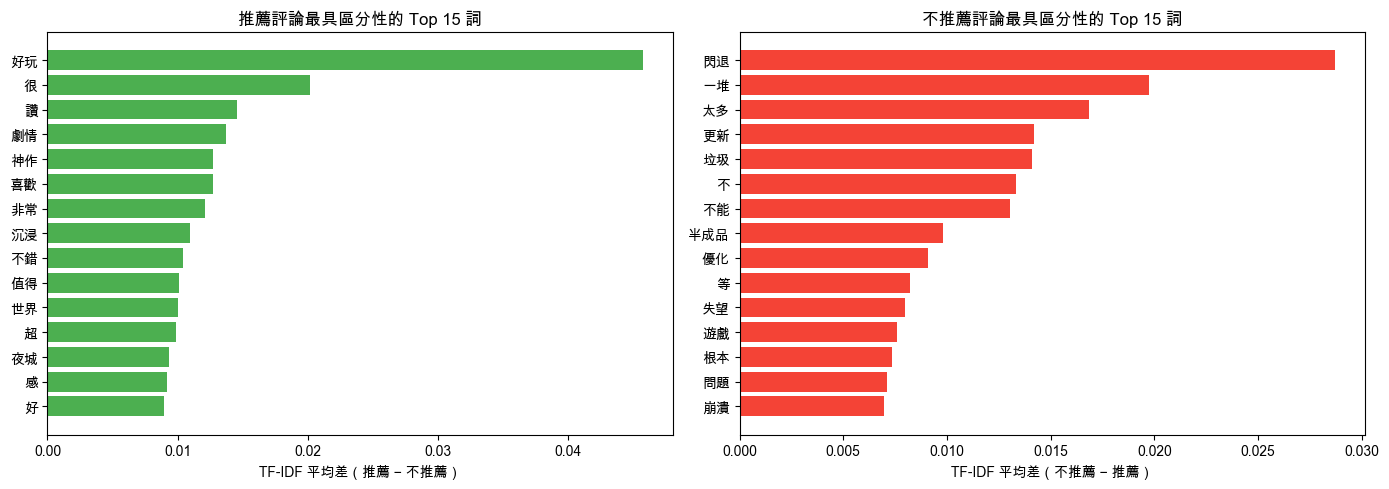

In [ ]:
# Distinctiveness = TF-IDF mean(推薦) − mean(不推薦).
# Words that are common to both classes (like 遊戲, 玩) cancel out;
# only words that lean toward one class survive in the top 15.
pos_mean = np.asarray(X[df['label'] == 1].mean(axis=0)).flatten()
neg_mean = np.asarray(X[df['label'] == 0].mean(axis=0)).flatten()
diff = pos_mean - neg_mean

top_pos = np.argsort(diff)[-15:]            # most 推薦-leaning, largest at chart top
top_neg = np.argsort(diff)[:15][::-1]       # most 不推薦-leaning, largest |diff| at chart top

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh([vocab[i] for i in top_pos], [diff[i] for i in top_pos], color='#4CAF50')
axes[0].set_title('推薦評論最具區分性的 Top 15 詞')
axes[0].set_xlabel('TF-IDF 平均差（推薦 − 不推薦）')

axes[1].barh([vocab[i] for i in top_neg], [-diff[i] for i in top_neg], color='#F44336')
axes[1].set_title('不推薦評論最具區分性的 Top 15 詞')
axes[1].set_xlabel('TF-IDF 平均差（不推薦 − 推薦）')

plt.tight_layout()
plt.show()


## Step 10：切分訓練／測試資料並訓練 Naive Bayes

In [ ]:
# Stratified split keeps the 推薦/不推薦 ratio in both train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'訓練資料：{X_train.shape[0]} 則')
print(f'測試資料：{X_test.shape[0]} 則')

model = MultinomialNB()
model.fit(X_train, y_train)
print('模型訓練完成')


訓練資料：2248 則
測試資料：563 則
模型訓練完成


## Step 11：算準確率

In [ ]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'模型準確率：{accuracy:.1%}')
print(f'  在 {len(y_test)} 則測試評論中猜對 {sum(y_pred == y_test)} 則')


模型準確率：84.0%
  在 563 則測試評論中猜對 473 則


## Step 12：混淆矩陣

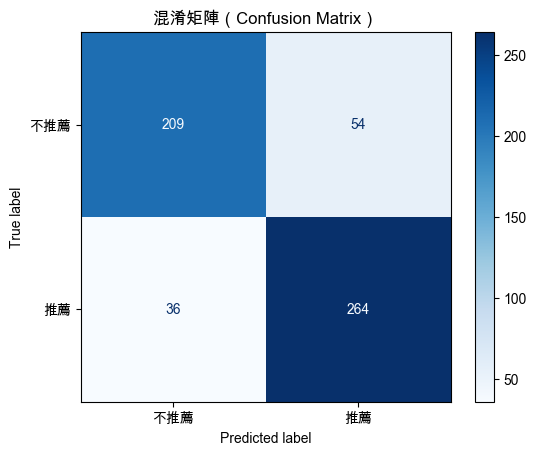

如何看這張圖：
  左上：實際不推薦、模型也猜不推薦（猜對）
  右下：實際推薦、模型也猜推薦（猜對）
  右上：實際不推薦、模型猜推薦（誤報）
  左下：實際推薦、模型猜不推薦（漏報）


In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['不推薦', '推薦'])
disp.plot(cmap='Blues')
plt.title('混淆矩陣（Confusion Matrix）')
plt.show()

print('如何看這張圖：')
print('  左上：實際不推薦、模型也猜不推薦（猜對）')
print('  右下：實際推薦、模型也猜推薦（猜對）')
print('  右上：實際不推薦、模型猜推薦（誤報）')
print('  左下：實際推薦、模型猜不推薦（漏報）')


## Step 13：預測新評論（內建範例）

In [ ]:
def predict_review(text):
    """Predict whether a review is 推薦 or 不推薦."""
    processed = preprocess(text)
    vector = tfidf.transform([processed])
    prediction = model.predict(vector)[0]
    proba = model.predict_proba(vector)[0]

    result = '推薦 ✅' if prediction == 1 else '不推薦 ❌'
    confidence = max(proba) * 100

    print(f'評論：{text}')
    print(f'預測：{result}（信心度：{confidence:.1f}%）')
    # 65% is a heuristic threshold for low-confidence (likely neutral) reviews
    if confidence < 65:
        print('warning: 信心度偏低，這則評論可能比較中性')
    print()

predict_review('劇情超讚 夜城設定太酷了')
predict_review('一直閃退 優化爛')
predict_review('還行吧 沒什麼特別的')


評論：劇情超讚 夜城設定太酷了
預測：推薦 ✅（信心度：94.6%）

評論：一直閃退 優化爛
預測：不推薦 ❌（信心度：86.6%）

評論：還行吧 沒什麼特別的
預測：推薦 ✅（信心度：65.2%）



## Exercise 3：自己輸入評論測試

In [ ]:
# 範例
my_review = '這 bug 真的『精彩』，笑死'
predict_review(my_review)

# 幫我把想預測的評論打在 '' 內
## ------------------------------------------
my_review = ''
predict_review(my_review)
## ------------------------------------------

評論：這 bug 真的『精彩』，笑死
預測：推薦 ✅（信心度：63.7%）

